
# 📈 Backtester V3 — Captura de giros y rebotes

Estrategia rediseñada para detectar **corrección → giro alcista → entrada → techo/giro bajista → salida**.

La idea ya no es exigir que RSI, Bollinger y volumen coincidan exactamente en una sola sesión.

## Entrada
1. Detecta **contexto de caída reciente** mediante drawdown desde un máximo reciente.
2. Comprueba si en los últimos días hubo **sobreventa** por RSI y/o perforación de Bollinger.
3. Espera un **giro alcista real**:
   - RSI subiendo
   - precio recuperando
   - ruptura del máximo anterior **o** cruce alcista de EMA corta
   - volumen razonable o creciente
4. Compra en la apertura de la sesión siguiente.

## Salida
1. Detecta sobreextensión / posible techo.
2. Espera pérdida de momentum.
3. Vende en la apertura siguiente.
4. Además mantiene un **trailing stop estructural** bajo mínimos recientes.

> Esto busca capturar mejor rebotes como el observado en META entre enero y febrero de 2026, sin volver a comprar simplemente porque "está sobrevendido".


In [40]:

# ================================================================
# ⚙️ CELDA 1 — CONFIGURACIÓN PRINCIPAL
# ================================================================
# 👉 MODIFICA NORMALMENTE SOLO ESTA CELDA
# ================================================================

# ------------------------------------------------
# 1️⃣ VALOR
# ------------------------------------------------
TICKER = "META"        # Meta
# TICKER = "AMZN"      # Amazon
# TICKER = "NVDA"      # NVIDIA
# TICKER = "MSFT"      # Microsoft
# TICKER = "AAPL"      # Apple
# TICKER = "GOOGL"     # Alphabet
# TICKER = "AVGO"      # Broadcom
# TICKER = "TSLA"      # Tesla
# TICKER = "COST"      # Costco
# TICKER = "NFLX"      # Netflix


# ------------------------------------------------
# 2️⃣ RANGO TOTAL DEL GRÁFICO
# ------------------------------------------------
FECHA_GRAFICA_INICIO = "2025-01-20"
FECHA_GRAFICA_FIN    = "2025-08-20"


# ------------------------------------------------
# 3️⃣ VENTANA OPERATIVA
# ------------------------------------------------
FECHA_OPERATIVA_INICIO = "2025-01-20"
FECHA_OPERATIVA_FIN    = "2025-08-20"


# ------------------------------------------------
# 4️⃣ CAPITAL
# ------------------------------------------------
CAPITAL_INICIAL = 10000.0
REINVERTIR_TODO = True


# ------------------------------------------------
# 5️⃣ RSI
# ------------------------------------------------
RSI_PERIODO = 14

# Se considera que hubo sobreventa si el RSI
# tocó este nivel durante los últimos días.
RSI_SOBREVENTA = 38

# Para salida
RSI_SOBRECOMPRA = 68


# ------------------------------------------------
# 6️⃣ BOLLINGER
# ------------------------------------------------
BB_PERIODO = 20
BB_DESVIACIONES = 2.0


# ------------------------------------------------
# 7️⃣ VOLUMEN
# ------------------------------------------------
VOLUMEN_PERIODO = 20

# No exigimos un pico enorme.
VOLUMEN_MIN_MULT = 0.95

# También aceptamos volumen creciente frente a la media de 3 sesiones.
VOLUMEN_CORTO = 3


# ------------------------------------------------
# 8️⃣ CONTEXTO DE CAÍDA
# ------------------------------------------------
# Máximo reciente desde el que calculamos drawdown.
LOOKBACK_MAXIMO = 12

# Caída mínima desde ese máximo.
DRAWDOWN_MIN_PCT = -5.0

# Buscamos evidencia de sobreventa en esta ventana.
LOOKBACK_SOBREVENTA = 7


# ------------------------------------------------
# 9️⃣ CONFIRMACIÓN DEL GIRO ALCISTA
# ------------------------------------------------
# EMAs cortas para detectar recuperación de momentum.
EMA_RAPIDA = 5
EMA_LENTA = 10

# Confirmaciones mínimas de giro.
# Se calculan sobre:
# 1 RSI subiendo
# 2 precio subiendo
# 3 ruptura máximo anterior
# 4 cruce/posición EMA alcista
# 5 volumen adecuado
# 6 cierre dentro de Bollinger
MIN_CONFIRMACIONES_ENTRADA = 4

# Evita comprar un rebote demasiado tarde:
# máximo porcentaje que permitimos recuperar desde el mínimo reciente.
MAX_REBOTE_DESDE_MINIMO_PCT = 15.0


# ------------------------------------------------
# 🔟 SALIDA / TECHO
# ------------------------------------------------
LOOKBACK_SUBIDA = 8
SUBIDA_MIN_PCT = 6.0

# Confirmaciones de giro bajista:
# RSI bajando, precio bajando, ruptura mínimo anterior,
# EMA pierde fuerza, volumen, reentrada desde Bollinger sup.
MIN_CONFIRMACIONES_SALIDA = 3


# ------------------------------------------------
# 1️⃣1️⃣ STOP ESTRUCTURAL
# ------------------------------------------------
# Stop inicial por debajo del mínimo reciente previo a la entrada.
LOOKBACK_MINIMO_STOP = 7
STOP_MARGEN_PCT = 1.5

# Trailing estructural
USAR_TRAILING = True
TRAILING_SESIONES = 4
TRAILING_MARGEN_PCT = 1.0

# No subir el trailing hasta que la operación haya ganado al menos:
TRAILING_ACTIVAR_GANANCIA_PCT = 3.0


# ------------------------------------------------
# 1️⃣2️⃣ COSTES
# ------------------------------------------------
COMISION_PCT = 0.0
SLIPPAGE_PCT = 0.0

DIAS_ESPERA_TRAS_SALIDA = 2


print("=" * 76)
print("📊 CONFIGURACIÓN V3")
print("=" * 76)
print(f"Ticker:                    {TICKER}")
print(f"Ventana:                   {FECHA_OPERATIVA_INICIO} → {FECHA_OPERATIVA_FIN}")
print(f"Drawdown mínimo:           {DRAWDOWN_MIN_PCT}%")
print(f"Lookback máximo:           {LOOKBACK_MAXIMO} sesiones")
print(f"RSI sobreventa:            {RSI_SOBREVENTA}")
print(f"Confirmaciones entrada:    {MIN_CONFIRMACIONES_ENTRADA}/6")
print(f"Confirmaciones salida:     {MIN_CONFIRMACIONES_SALIDA}/6")
print(f"Capital inicial:           ${CAPITAL_INICIAL:,.2f}")
print("=" * 76)


📊 CONFIGURACIÓN V3
Ticker:                    META
Ventana:                   2025-01-20 → 2025-08-20
Drawdown mínimo:           -5.0%
Lookback máximo:           12 sesiones
RSI sobreventa:            38
Confirmaciones entrada:    4/6
Confirmaciones salida:     3/6
Capital inicial:           $10,000.00


In [41]:

# ================================================================
# 📦 CELDA 2 — LIBRERÍAS
# ================================================================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 190)

print("✅ Librerías cargadas")


✅ Librerías cargadas


In [42]:

# ================================================================
# 📥 CELDA 3 — DESCARGA DE DATOS
# ================================================================
df = yf.download(
    TICKER,
    start=FECHA_GRAFICA_INICIO,
    end=FECHA_GRAFICA_FIN,
    interval="1d",
    auto_adjust=False,
    progress=False
)

if df.empty:
    raise ValueError("No se han descargado datos.")

df = df.reset_index()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]

cols = ["Date", "Open", "High", "Low", "Close", "Volume"]
df = df[[c for c in cols if c in df.columns]].copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

print(f"✅ {len(df)} sesiones")
print(df["Date"].min().date(), "→", df["Date"].max().date())
display(df.tail())


✅ 146 sesiones
2025-01-21 → 2025-08-19


,Date,Open,High,Low,Close,Volume
141,2025-08-13,791.150024,795.460022,778.229980,780.080017,8811800
142,2025-08-14,777.880005,787.809998,772.510010,782.130005,8116200
143,2025-08-15,784.150024,796.250000,780.820007,785.229980,13375400
144,2025-08-18,775.090027,775.809998,756.559998,767.369995,16513700
145,2025-08-19,767.119995,767.169983,749.359985,751.479980,12286700


In [43]:

# ================================================================
# 🧮 CELDA 4 — INDICADORES
# ================================================================
data = df.copy()

# RSI Wilder
delta = data["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.ewm(
    alpha=1/RSI_PERIODO,
    adjust=False,
    min_periods=RSI_PERIODO
).mean()

avg_loss = loss.ewm(
    alpha=1/RSI_PERIODO,
    adjust=False,
    min_periods=RSI_PERIODO
).mean()

rs = avg_gain / avg_loss.replace(0, np.nan)
data["RSI"] = 100 - (100 / (1 + rs))

# Bollinger
data["BB_Media"] = data["Close"].rolling(BB_PERIODO).mean()
bb_std = data["Close"].rolling(BB_PERIODO).std(ddof=0)
data["BB_Sup"] = data["BB_Media"] + BB_DESVIACIONES * bb_std
data["BB_Inf"] = data["BB_Media"] - BB_DESVIACIONES * bb_std

# Volumen
data["Vol_Media"] = data["Volume"].rolling(VOLUMEN_PERIODO).mean()
data["Vol_Corto"] = data["Volume"].rolling(VOLUMEN_CORTO).mean()

# EMA
data["EMA_Rapida"] = data["Close"].ewm(span=EMA_RAPIDA, adjust=False).mean()
data["EMA_Lenta"] = data["Close"].ewm(span=EMA_LENTA, adjust=False).mean()

# Drawdown desde máximo reciente
data["Max_Reciente"] = data["High"].rolling(LOOKBACK_MAXIMO).max()
data["Drawdown_Pct"] = (
    data["Close"] / data["Max_Reciente"] - 1
) * 100

# Mínimo reciente y rebote desde mínimo
data["Min_Reciente"] = data["Low"].rolling(LOOKBACK_SOBREVENTA).min()
data["Rebote_Desde_Min_Pct"] = (
    data["Close"] / data["Min_Reciente"] - 1
) * 100

# Subida reciente para buscar techo
data["Subida_Reciente_Pct"] = (
    data["Close"] / data["Close"].shift(LOOKBACK_SUBIDA) - 1
) * 100

print("✅ Indicadores calculados")


✅ Indicadores calculados


In [44]:

# ================================================================
# 🟡 CELDA 5 — CONTEXTO DE CAÍDA / OPORTUNIDAD
# ================================================================
sig = data.copy()

# Evidencia histórica reciente, no necesariamente hoy.
sig["RSI_Min_Reciente"] = sig["RSI"].rolling(LOOKBACK_SOBREVENTA).min()

# ¿Durante los últimos días se perforó Bollinger inferior?
perforo_bb = (sig["Low"] <= sig["BB_Inf"]).astype(int)
sig["Perforo_BB_Reciente"] = (
    perforo_bb.rolling(LOOKBACK_SOBREVENTA).max() > 0
)

sig["RSI_Sobreventa_Reciente"] = (
    sig["RSI_Min_Reciente"] <= RSI_SOBREVENTA
)

# Contexto bajista:
# drawdown suficiente + (RSI sobrevendido O perforación Bollinger)
sig["Contexto_Caida"] = (
    (sig["Drawdown_Pct"] <= DRAWDOWN_MIN_PCT) &
    (
        sig["RSI_Sobreventa_Reciente"] |
        sig["Perforo_BB_Reciente"]
    )
)

print("✅ Contexto de caída preparado")


✅ Contexto de caída preparado


In [45]:

# ================================================================
# 🟢 CELDA 6 — CONFIRMACIÓN DEL GIRO ALCISTA
# ================================================================

sig["ENT_RSI"] = sig["RSI"] > sig["RSI"].shift(1)

sig["ENT_PRECIO"] = sig["Close"] > sig["Close"].shift(1)

sig["ENT_ROMPE_MAX"] = (
    sig["Close"] > sig["High"].shift(1)
)

# EMA: aceptamos cruce o ya posición alcista con pendiente positiva
sig["ENT_EMA"] = (
    (
        (sig["EMA_Rapida"].shift(1) <= sig["EMA_Lenta"].shift(1)) &
        (sig["EMA_Rapida"] > sig["EMA_Lenta"])
    )
    |
    (
        (sig["EMA_Rapida"] > sig["EMA_Lenta"]) &
        (sig["EMA_Rapida"] > sig["EMA_Rapida"].shift(1))
    )
)

# Volumen: basta con volumen casi en media O aceleración frente a media corta
sig["ENT_VOLUMEN"] = (
    (sig["Volume"] >= sig["Vol_Media"] * VOLUMEN_MIN_MULT)
    |
    (sig["Volume"] > sig["Vol_Corto"].shift(1))
)

sig["ENT_BOLLINGER"] = sig["Close"] > sig["BB_Inf"]

entrada_cols = [
    "ENT_RSI",
    "ENT_PRECIO",
    "ENT_ROMPE_MAX",
    "ENT_EMA",
    "ENT_VOLUMEN",
    "ENT_BOLLINGER"
]

sig["Confirmaciones_Entrada"] = sig[entrada_cols].sum(axis=1)

# Giro técnicamente válido.
sig["Giro_Alcista"] = (
    (sig["Confirmaciones_Entrada"] >= MIN_CONFIRMACIONES_ENTRADA)
    &
    (sig["Rebote_Desde_Min_Pct"] <= MAX_REBOTE_DESDE_MINIMO_PCT)
)

# Entrada autorizada:
# contexto de caída ACTUAL o muy reciente.
contexto_reciente = sig["Contexto_Caida"].astype(int).rolling(
    LOOKBACK_SOBREVENTA
).max() > 0

sig["Entrada_Autorizada"] = (
    contexto_reciente &
    sig["Giro_Alcista"]
)

print("✅ Lógica de entrada preparada")


✅ Lógica de entrada preparada


In [46]:

# ================================================================
# 🔴 CELDA 7 — TECHO Y GIRO BAJISTA
# ================================================================

# Contexto de sobreextensión
sig["Sobreextendido"] = (
    (sig["RSI"] >= RSI_SOBRECOMPRA)
    |
    (sig["Close"] >= sig["BB_Sup"])
    |
    (sig["Subida_Reciente_Pct"] >= SUBIDA_MIN_PCT)
)

# Confirmaciones de deterioro
sig["SAL_RSI"] = sig["RSI"] < sig["RSI"].shift(1)
sig["SAL_PRECIO"] = sig["Close"] < sig["Close"].shift(1)
sig["SAL_ROMPE_MIN"] = sig["Close"] < sig["Low"].shift(1)

sig["SAL_EMA"] = (
    (sig["EMA_Rapida"] < sig["EMA_Rapida"].shift(1))
    |
    (sig["EMA_Rapida"] < sig["EMA_Lenta"])
)

sig["SAL_VOLUMEN"] = (
    (sig["Volume"] >= sig["Vol_Media"] * VOLUMEN_MIN_MULT)
    |
    (sig["Volume"] > sig["Vol_Corto"].shift(1))
)

sig["SAL_BOLLINGER"] = sig["Close"] < sig["BB_Sup"]

salida_cols = [
    "SAL_RSI",
    "SAL_PRECIO",
    "SAL_ROMPE_MIN",
    "SAL_EMA",
    "SAL_VOLUMEN",
    "SAL_BOLLINGER"
]

sig["Confirmaciones_Salida"] = sig[salida_cols].sum(axis=1)

# Un techo reciente habilita la salida.
techo_reciente = sig["Sobreextendido"].astype(int).rolling(5).max() > 0

sig["Salida_Autorizada"] = (
    techo_reciente &
    (sig["Confirmaciones_Salida"] >= MIN_CONFIRMACIONES_SALIDA)
)

print("✅ Lógica de salida preparada")


✅ Lógica de salida preparada


In [47]:

# ================================================================
# 🧪 CELDA 8 — MOTOR DE BACKTEST
# ================================================================

fecha_ini = pd.Timestamp(FECHA_OPERATIVA_INICIO)
fecha_fin = pd.Timestamp(FECHA_OPERATIVA_FIN)

capital = float(CAPITAL_INICIAL)

en_posicion = False
entrada = {}
operaciones = []
eventos = []
ultima_salida_idx = -999

for i in range(max(LOOKBACK_MAXIMO, BB_PERIODO, RSI_PERIODO), len(sig)-1):

    hoy = sig.iloc[i]
    manana = sig.iloc[i+1]
    fecha_hoy = hoy["Date"]
    fecha_manana = manana["Date"]

    # ------------------------------------------------------------
    # SI ESTAMOS FUERA
    # ------------------------------------------------------------
    if not en_posicion:

        if i - ultima_salida_idx <= DIAS_ESPERA_TRAS_SALIDA:
            continue

        # Registrar contexto bajista
        if bool(hoy["Contexto_Caida"]):
            eventos.append({
                "Fecha": fecha_hoy,
                "Evento": "CONTEXTO DE CAÍDA",
                "Precio": hoy["Close"],
                "Conf": int(hoy["Confirmaciones_Entrada"])
            })

        # Compra solo si mañana está dentro de la ventana
        if (
            bool(hoy["Entrada_Autorizada"])
            and fecha_manana >= fecha_ini
            and fecha_manana <= fecha_fin
        ):

            precio_entrada = manana["Open"] * (1 + SLIPPAGE_PCT/100)

            capital_operar = capital if REINVERTIR_TODO else CAPITAL_INICIAL

            factor_comision = 1 + COMISION_PCT/100
            acciones = capital_operar / (precio_entrada * factor_comision)

            importe_compra = acciones * precio_entrada
            coste_compra = importe_compra * COMISION_PCT/100
            capital_invertido_neto = importe_compra + coste_compra

            minimo_stop = sig.iloc[
                max(0, i-LOOKBACK_MINIMO_STOP+1):i+1
            ]["Low"].min()

            stop_inicial = minimo_stop * (1 - STOP_MARGEN_PCT/100)

            entrada = {
                "fecha": fecha_manana,
                "precio": precio_entrada,
                "acciones": acciones,
                "capital_antes": capital,
                "capital_invertido_neto": capital_invertido_neto,
                "stop_inicial": stop_inicial,
                "stop_actual": stop_inicial,
                "confirmaciones": int(hoy["Confirmaciones_Entrada"])
            }

            eventos.append({
                "Fecha": fecha_manana,
                "Evento": "COMPRA",
                "Precio": precio_entrada,
                "Conf": int(hoy["Confirmaciones_Entrada"])
            })

            en_posicion = True

        continue

    # ------------------------------------------------------------
    # SI ESTAMOS DENTRO
    # ------------------------------------------------------------

    # Activar trailing solo con beneficio suficiente
    beneficio_actual_pct = (
        hoy["Close"] / entrada["precio"] - 1
    ) * 100

    if (
        USAR_TRAILING
        and beneficio_actual_pct >= TRAILING_ACTIVAR_GANANCIA_PCT
        and i >= TRAILING_SESIONES
    ):
        minimo_trailing = sig.iloc[
            i-TRAILING_SESIONES:i
        ]["Low"].min()

        nuevo_stop = minimo_trailing * (
            1 - TRAILING_MARGEN_PCT/100
        )

        entrada["stop_actual"] = max(
            entrada["stop_actual"],
            nuevo_stop
        )

    # STOP intradía
    if hoy["Low"] <= entrada["stop_actual"]:

        precio_salida = entrada["stop_actual"] * (
            1 - SLIPPAGE_PCT/100
        )

        importe_salida = entrada["acciones"] * precio_salida
        coste_salida = importe_salida * COMISION_PCT/100
        capital_final = importe_salida - coste_salida

        ganancia_pct = (
            capital_final / entrada["capital_invertido_neto"] - 1
        ) * 100

        capital = capital_final

        operaciones.append({
            "Entrada": entrada["fecha"],
            "Precio entrada": entrada["precio"],
            "Salida": fecha_hoy,
            "Precio salida": precio_salida,
            "Motivo salida": "STOP/TRAILING",
            "Ganancia %": ganancia_pct,
            "Capital antes": entrada["capital_antes"],
            "Capital después": capital,
            "Confirmaciones entrada": entrada["confirmaciones"],
            "Stop inicial": entrada["stop_inicial"],
            "Stop final": entrada["stop_actual"]
        })

        eventos.append({
            "Fecha": fecha_hoy,
            "Evento": "VENTA STOP/TRAILING",
            "Precio": precio_salida,
            "Conf": np.nan
        })

        en_posicion = False
        entrada = {}
        ultima_salida_idx = i
        continue

    # SALIDA TÉCNICA: señal hoy -> apertura mañana
    if (
        bool(hoy["Salida_Autorizada"])
        and fecha_manana <= fecha_fin
    ):

        precio_salida = manana["Open"] * (
            1 - SLIPPAGE_PCT/100
        )

        importe_salida = entrada["acciones"] * precio_salida
        coste_salida = importe_salida * COMISION_PCT/100
        capital_final = importe_salida - coste_salida

        ganancia_pct = (
            capital_final / entrada["capital_invertido_neto"] - 1
        ) * 100

        capital = capital_final

        operaciones.append({
            "Entrada": entrada["fecha"],
            "Precio entrada": entrada["precio"],
            "Salida": fecha_manana,
            "Precio salida": precio_salida,
            "Motivo salida": "GIRO BAJISTA",
            "Ganancia %": ganancia_pct,
            "Capital antes": entrada["capital_antes"],
            "Capital después": capital,
            "Confirmaciones entrada": entrada["confirmaciones"],
            "Stop inicial": entrada["stop_inicial"],
            "Stop final": entrada["stop_actual"]
        })

        eventos.append({
            "Fecha": fecha_manana,
            "Evento": "VENTA GIRO BAJISTA",
            "Precio": precio_salida,
            "Conf": int(hoy["Confirmaciones_Salida"])
        })

        en_posicion = False
        entrada = {}
        ultima_salida_idx = i


# ------------------------------------------------
# REGLA FINAL:
# operación abierta al terminar la ventana = ANULADA
# ------------------------------------------------
operacion_anulada = None

if en_posicion:
    operacion_anulada = {
        "Entrada anulada": entrada["fecha"],
        "Precio entrada": entrada["precio"],
        "Motivo": "Operación aún abierta al finalizar la ventana"
    }

    capital = entrada["capital_antes"]
    en_posicion = False
    entrada = {}

ops = pd.DataFrame(operaciones)
eventos_df = pd.DataFrame(eventos)

print("=" * 80)
print("✅ BACKTEST FINALIZADO")
print("=" * 80)
print(f"Capital inicial: ${CAPITAL_INICIAL:,.2f}")
print(f"Capital final:   ${capital:,.2f}")
print(f"Rentabilidad:    {(capital/CAPITAL_INICIAL - 1)*100:+.2f}%")
print(f"Operaciones:     {len(ops)}")

if operacion_anulada:
    print("⚠️ Hay una operación anulada por terminar abierta.")


✅ BACKTEST FINALIZADO
Capital inicial: $10,000.00
Capital final:   $8,805.81
Rentabilidad:    -11.94%
Operaciones:     6


In [48]:

# ================================================================
# 📋 CELDA 9 — TABLA DE OPERACIONES
# ================================================================
if ops.empty:
    print("No hay operaciones cerradas.")
else:
    tabla = ops.copy()

    for c in [
        "Precio entrada", "Precio salida",
        "Capital antes", "Capital después",
        "Stop inicial", "Stop final"
    ]:
        tabla[c] = tabla[c].round(2)

    tabla["Ganancia %"] = tabla["Ganancia %"].round(2)

    display(tabla)

if operacion_anulada:
    print()
    display(pd.DataFrame([operacion_anulada]))


,Entrada,Precio entrada,Salida,Precio salida,Motivo salida,Ganancia %,Capital antes,Capital después,Confirmaciones entrada,Stop inicial,Stop final
0,2025-02-27,682.45,2025-03-04,632.23,STOP/TRAILING,-7.36,10000.00,9264.15,4,632.23,632.23
1,2025-03-12,629.90,2025-03-18,578.07,STOP/TRAILING,-8.23,9264.15,8501.83,4,578.07,578.07
2,2025-03-24,614.97,2025-03-27,602.00,GIRO BAJISTA,-2.11,8501.83,8322.52,4,566.04,566.04
3,2025-04-02,574.91,2025-04-03,545.00,STOP/TRAILING,-5.20,8322.52,7889.54,4,545.00,545.00
4,2025-04-23,528.53,2025-05-01,592.08,GIRO BAJISTA,12.02,7889.54,8838.17,5,472.60,512.33
5,2025-05-06,592.53,2025-05-07,590.36,GIRO BAJISTA,-0.37,8838.17,8805.81,4,521.56,521.56


In [49]:

# ================================================================
# 🧭 CELDA 10 — EVENTOS / DIAGNÓSTICO
# ================================================================
if eventos_df.empty:
    print("No hay eventos.")
else:
    display(eventos_df)


,Fecha,Evento,Precio,Conf
0,2025-02-25,CONTEXTO DE CAÍDA,657.500000,1.0
1,2025-02-26,CONTEXTO DE CAÍDA,673.700012,4.0
2,2025-02-27,COMPRA,682.450012,4.0
3,2025-03-04,VENTA STOP/TRAILING,632.232086,NaN
4,2025-03-07,CONTEXTO DE CAÍDA,625.659973,2.0
5,2025-03-10,CONTEXTO DE CAÍDA,597.989990,1.0
6,2025-03-11,CONTEXTO DE CAÍDA,605.710022,4.0
7,2025-03-12,COMPRA,629.900024,4.0
8,2025-03-18,VENTA STOP/TRAILING,578.066945,NaN
9,2025-03-21,CONTEXTO DE CAÍDA,596.250000,4.0


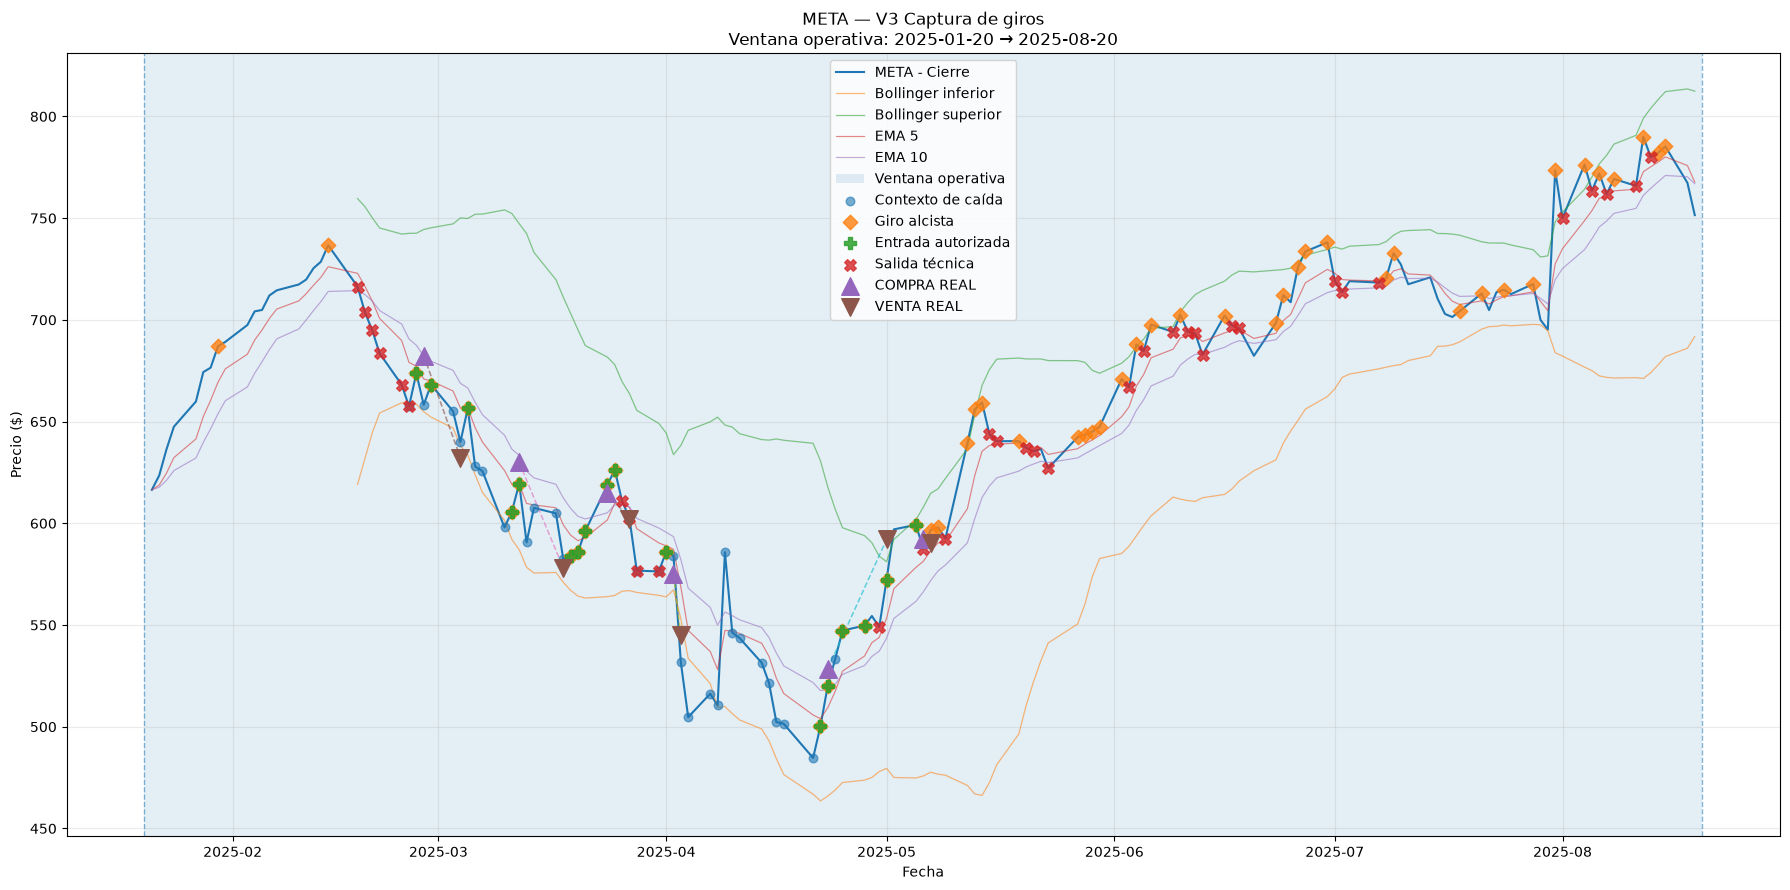


🔎 RESUMEN DE SEÑALES
Contextos de caída:       40
Giros alcistas:           52
Entradas autorizadas:     17
Salidas autorizadas:      34
Operaciones completadas:  6


In [50]:

# ================================================================
# 📈 CELDA 11 — GRÁFICA FINAL
# ================================================================
# Siempre se muestra.
# ================================================================

fig, ax = plt.subplots(figsize=(18, 9))

# Precio
ax.plot(
    sig["Date"],
    sig["Close"],
    linewidth=1.5,
    label=f"{TICKER} - Cierre"
)

# Bollinger
ax.plot(
    sig["Date"],
    sig["BB_Inf"],
    linewidth=0.9,
    alpha=0.55,
    label="Bollinger inferior"
)

ax.plot(
    sig["Date"],
    sig["BB_Sup"],
    linewidth=0.9,
    alpha=0.55,
    label="Bollinger superior"
)

# EMAs
ax.plot(
    sig["Date"],
    sig["EMA_Rapida"],
    linewidth=0.85,
    alpha=0.55,
    label=f"EMA {EMA_RAPIDA}"
)

ax.plot(
    sig["Date"],
    sig["EMA_Lenta"],
    linewidth=0.85,
    alpha=0.55,
    label=f"EMA {EMA_LENTA}"
)

# Ventana operativa
ax.axvspan(
    fecha_ini,
    fecha_fin,
    alpha=0.12,
    label="Ventana operativa"
)

ax.axvline(fecha_ini, linestyle="--", linewidth=1, alpha=0.55)
ax.axvline(fecha_fin, linestyle="--", linewidth=1, alpha=0.55)

# Contexto de caída
ctx = sig[sig["Contexto_Caida"]]
if not ctx.empty:
    ax.scatter(
        ctx["Date"],
        ctx["Close"],
        marker="o",
        s=38,
        alpha=0.60,
        label="Contexto de caída",
        zorder=5
    )

# Giro alcista técnico
giro = sig[sig["Giro_Alcista"]]
if not giro.empty:
    ax.scatter(
        giro["Date"],
        giro["Close"],
        marker="D",
        s=55,
        alpha=0.8,
        label="Giro alcista",
        zorder=6
    )

# Entrada autorizada
aut = sig[sig["Entrada_Autorizada"]]
if not aut.empty:
    ax.scatter(
        aut["Date"],
        aut["Close"],
        marker="P",
        s=80,
        alpha=0.85,
        label="Entrada autorizada",
        zorder=7
    )

# Salida técnica autorizada
sal = sig[sig["Salida_Autorizada"]]
if not sal.empty:
    ax.scatter(
        sal["Date"],
        sal["Close"],
        marker="X",
        s=70,
        alpha=0.8,
        label="Salida técnica",
        zorder=7
    )

# Operaciones reales
if not ops.empty:
    ax.scatter(
        ops["Entrada"],
        ops["Precio entrada"],
        marker="^",
        s=160,
        label="COMPRA REAL",
        zorder=10
    )

    ax.scatter(
        ops["Salida"],
        ops["Precio salida"],
        marker="v",
        s=160,
        label="VENTA REAL",
        zorder=10
    )

    for _, op in ops.iterrows():
        ax.plot(
            [op["Entrada"], op["Salida"]],
            [op["Precio entrada"], op["Precio salida"]],
            linestyle="--",
            linewidth=1.1,
            alpha=0.65
        )

if operacion_anulada:
    ax.scatter(
        [operacion_anulada["Entrada anulada"]],
        [operacion_anulada["Precio entrada"]],
        marker="x",
        s=160,
        linewidths=2.5,
        label="Entrada anulada",
        zorder=11
    )

ax.set_title(
    f"{TICKER} — V3 Captura de giros\n"
    f"Ventana operativa: {FECHA_OPERATIVA_INICIO} → {FECHA_OPERATIVA_FIN}"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Precio ($)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

print()
print("=" * 76)
print("🔎 RESUMEN DE SEÑALES")
print("=" * 76)
print(f"Contextos de caída:       {int(sig['Contexto_Caida'].sum())}")
print(f"Giros alcistas:           {int(sig['Giro_Alcista'].sum())}")
print(f"Entradas autorizadas:     {int(sig['Entrada_Autorizada'].sum())}")
print(f"Salidas autorizadas:      {int(sig['Salida_Autorizada'].sum())}")
print(f"Operaciones completadas:  {len(ops)}")
print("=" * 76)


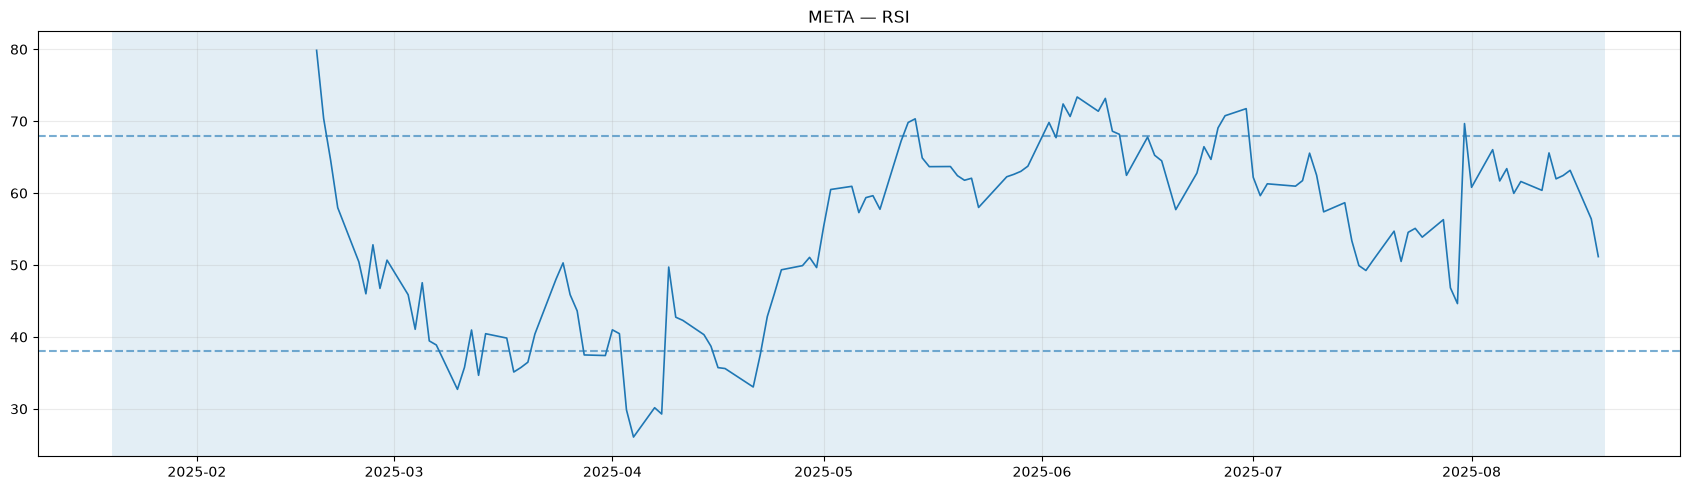

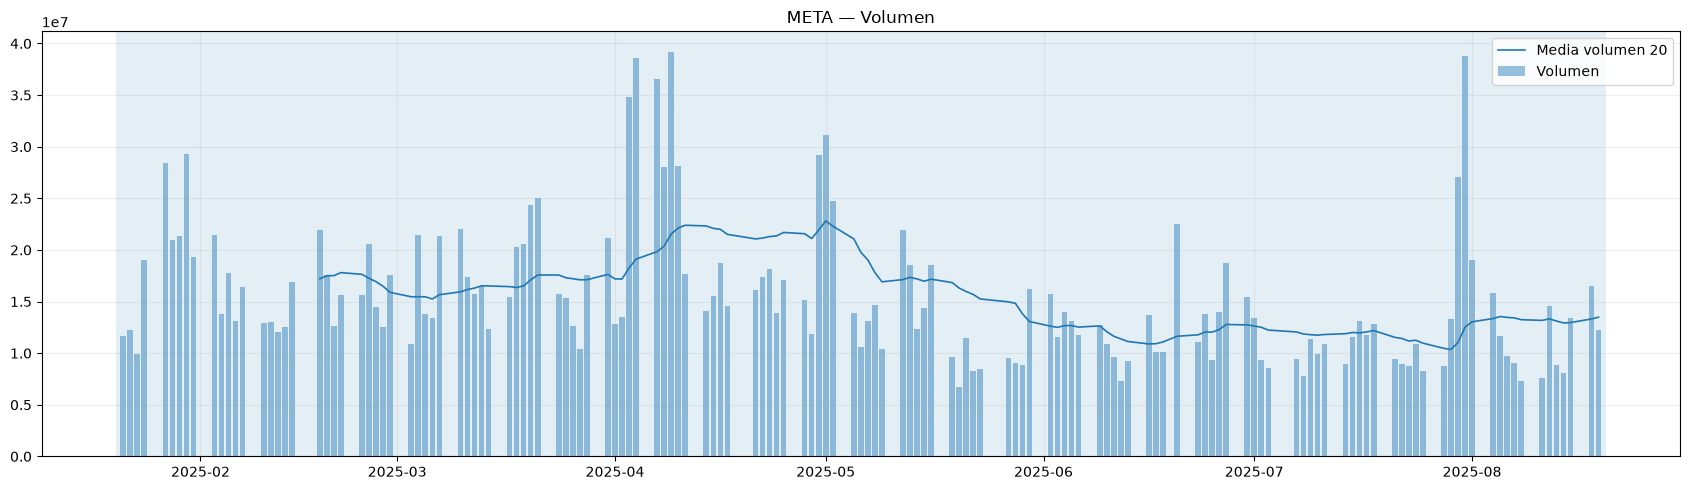

In [51]:

# ================================================================
# 📊 CELDA 12 — RSI Y VOLUMEN
# ================================================================

plt.figure(figsize=(17, 5))
plt.plot(sig["Date"], sig["RSI"], linewidth=1.2)
plt.axhline(RSI_SOBREVENTA, linestyle="--", alpha=0.6)
plt.axhline(RSI_SOBRECOMPRA, linestyle="--", alpha=0.6)
plt.axvspan(fecha_ini, fecha_fin, alpha=0.12)
plt.title(f"{TICKER} — RSI")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(17, 5))
plt.bar(sig["Date"], sig["Volume"], alpha=0.45, label="Volumen")
plt.plot(
    sig["Date"],
    sig["Vol_Media"],
    linewidth=1.2,
    label=f"Media volumen {VOLUMEN_PERIODO}"
)
plt.axvspan(fecha_ini, fecha_fin, alpha=0.12)
plt.title(f"{TICKER} — Volumen")
plt.grid(True, alpha=0.20)
plt.legend()
plt.tight_layout()
plt.show()


In [52]:

# ================================================================
# 💾 CELDA 13 — GUARDAR RESULTADOS
# ================================================================

if not ops.empty:
    nombre = (
        f"GIROS_V3_{TICKER}_"
        f"{FECHA_OPERATIVA_INICIO}_"
        f"{FECHA_OPERATIVA_FIN}.csv"
    )
    ops.to_csv(nombre, index=False)
    print(f"✅ Guardado: {nombre}")
else:
    print("No hay operaciones para guardar.")


✅ Guardado: GIROS_V3_META_2025-01-20_2025-08-20.csv



## Qué hemos cambiado respecto a V2

La V2 dependía demasiado de que una “caída fuerte” concreta se detectara antes del rebote.

La V3 usa una **memoria reciente**:

- drawdown desde máximo reciente,
- RSI mínimo de varios días,
- perforación de Bollinger en los últimos días.

Después puntúa el giro con seis confirmaciones. No exige que todas ocurran exactamente a la vez.

Esto reduce el riesgo de que el sistema vea claramente un rebote en la gráfica pero se niegue a entrar porque “no estaba en el estado correcto”.

### Advertencia sobre optimización

Si modificamos parámetros mirando únicamente META enero-febrero de 2026, podemos terminar sobreajustando la estrategia a ese tramo. Después de conseguir una lógica razonable aquí, conviene probarla en otras ventanas y en AMZN/NVDA/MSFT sin cambiar parámetros.
